Saved → drug_price_purity_charts.png


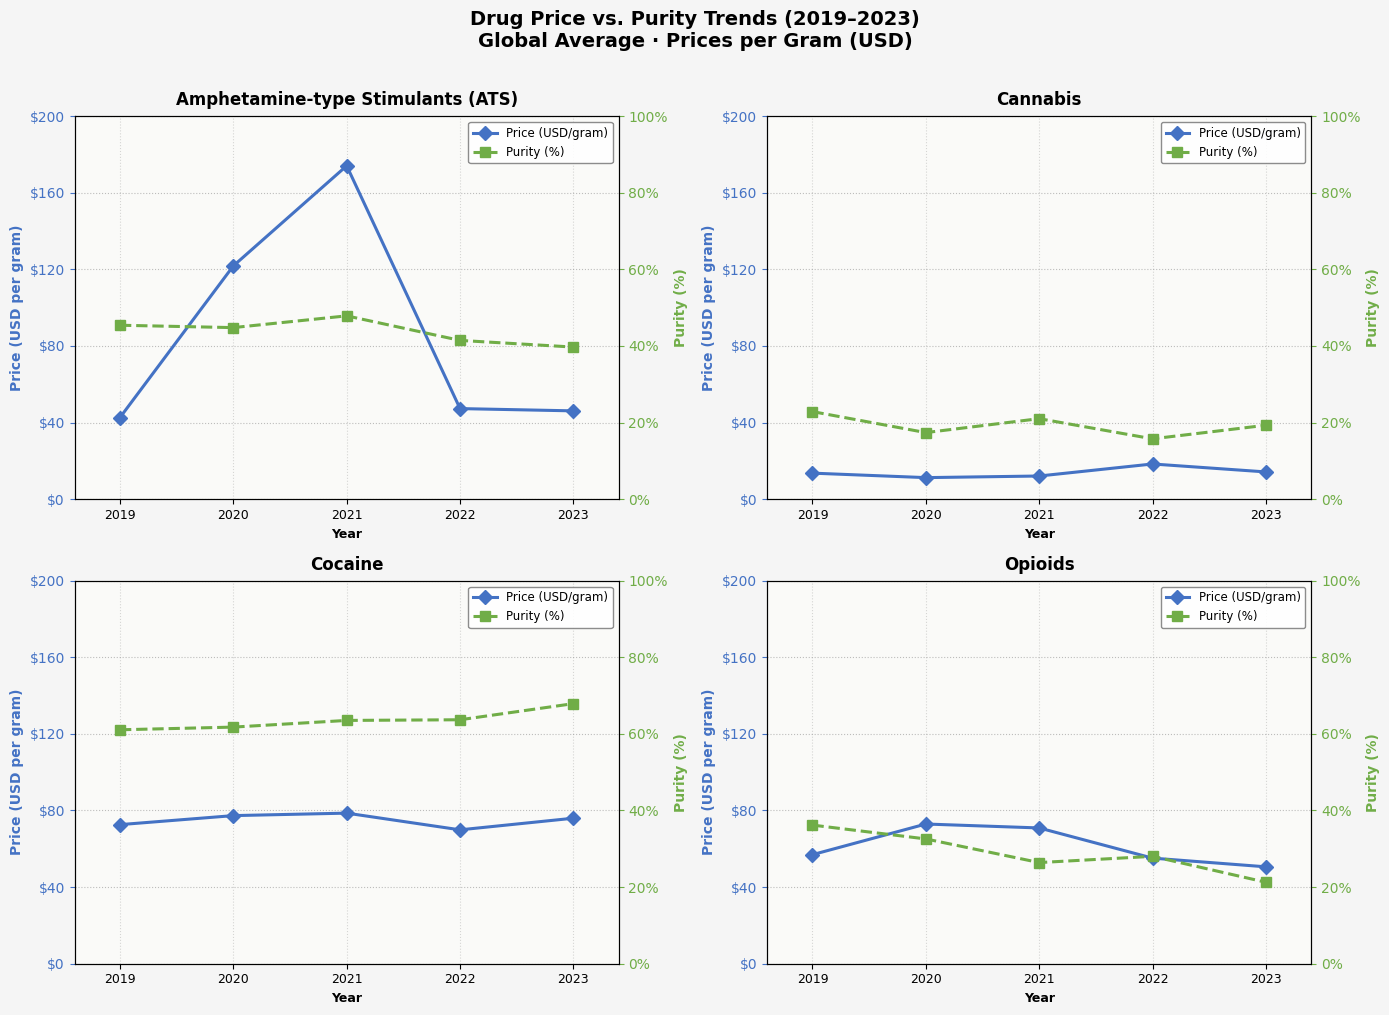

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

PRICES_CSV  = 'slide8_prezzi.csv'
PURITY_CSV  = 'slide8_purezza.csv'
OUTPUT_FILE = 'drug_price_purity_charts.png'

df_p = pd.read_csv(PRICES_CSV, sep=';', header=1)
df_u = pd.read_csv(PURITY_CSV, sep=';', header=1)

df_p['Typical_USD'] = (df_p['Typical_USD'].astype(str)
                        .str.replace('$', '', regex=False)
                        .str.strip()
                        .str.replace('.', '', regex=False)   
                        .str.replace(',', '.', regex=False)) 
df_p['Typical_USD'] = pd.to_numeric(df_p['Typical_USD'], errors='coerce')
df_p['Year'] = pd.to_numeric(df_p['Year'], errors='coerce')

df_u['Typical'] = pd.to_numeric(
    df_u['Typical'].astype(str).str.replace(',', '.', regex=False), errors='coerce')
df_u['Year'] = pd.to_numeric(df_u['Year'], errors='coerce')
df_u = df_u[df_u['Measurement'].astype(str).str.contains('%', na=False)]

YEARS = list(range(2019, 2024))
df_p = df_p[df_p['Year'].isin(YEARS)]
df_u = df_u[df_u['Year'].isin(YEARS)]

def categorize(dg):
    if pd.isna(dg): return None
    d = str(dg).lower()
    if 'amphetamine' in d or d == 'ats': return 'Amphetamines (ATS)'
    if 'cannabis' in d:                  return 'Cannabis'
    if 'cocaine' in d:                   return 'Cocaine'
    if 'opioid' in d:                    return 'Opioids'
    return None

df_p['Category'] = df_p['DrugGroup'].apply(categorize)
df_u['Category'] = df_u['DrugGroup'].apply(categorize)

GRAM_UNITS = {'Grams': 1.0, 'Gram': 1.0, 'Kilograms': 1/1000, 'Kilogram': 1/1000}

def agg_price(df_sub):
    sub = df_sub[df_sub['Unit'].isin(GRAM_UNITS)].copy()
    sub['Price_norm'] = sub.apply(
        lambda r: r['Typical_USD'] * GRAM_UNITS[r['Unit']], axis=1)
    return sub.dropna(subset=['Price_norm']).groupby('Year')['Price_norm'].mean().reset_index()

CATEGORIES = ['Amphetamines (ATS)', 'Cannabis', 'Cocaine', 'Opioids']

data = {}
for cat in CATEGORIES:
    price_agg  = agg_price(df_p[df_p['Category'] == cat])
    purity_agg = (df_u[df_u['Category'] == cat]
                  .dropna(subset=['Typical'])
                  .groupby('Year')['Typical'].mean().reset_index())
    data[cat] = {'price': price_agg, 'purity': purity_agg}

all_prices = pd.concat([d['price']['Price_norm'] for d in data.values()])
price_max = np.ceil(all_prices.max() * 1.1 / 10) * 10   

COLOR_PRICE  = '#4472C4'   
COLOR_PURITY = '#70AD47'   

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('#F5F5F5')

TITLES = {
    'Amphetamines (ATS)': 'Amphetamine-type Stimulants (ATS)',
    'Cannabis':           'Cannabis',
    'Cocaine':            'Cocaine',
    'Opioids':            'Opioids',
}

for ax, cat in zip(axes.flat, CATEGORIES):
    pr = data[cat]['price'].sort_values('Year')
    pu = data[cat]['purity'].sort_values('Year')

    ax.set_facecolor('#FAFAF8')

    ax.set_xlim(2018.6, 2023.4)
    ax.set_ylim(0, price_max)
    ax.set_yticks(np.linspace(0, price_max, 6))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0f'))
    ax.tick_params(axis='y', colors=COLOR_PRICE)
    ax.set_ylabel('Price (USD per gram)', color=COLOR_PRICE, fontsize=10, fontweight='bold')

    l1, = ax.plot(pr['Year'], pr['Price_norm'],
                  color=COLOR_PRICE, linewidth=2.2, marker='D',
                  markersize=7, label='Price (USD/gram)', zorder=3)

    ax2 = ax.twinx()
    ax2.set_ylim(0, 100)
    ax2.set_yticks(range(0, 101, 20))
    ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
    ax2.tick_params(axis='y', colors=COLOR_PURITY)
    ax2.set_ylabel('Purity (%)', color=COLOR_PURITY, fontsize=10, fontweight='bold')

    l2, = ax2.plot(pu['Year'], pu['Typical'],
                   color=COLOR_PURITY, linewidth=2.2, marker='s',
                   markersize=7, linestyle='--', label='Purity (%)', zorder=3)

    ax.set_xticks(YEARS)
    ax.set_xticklabels([str(y) for y in YEARS], fontsize=9)
    ax.set_xlabel('Year', fontsize=9, fontweight='bold')

    ax.grid(True, axis='y', linestyle=':', alpha=0.5, color='grey')
    ax.grid(True, axis='x', linestyle=':', alpha=0.3, color='grey')

    ax.set_title(TITLES[cat], fontsize=12, fontweight='bold', pad=8)
    ax.legend(handles=[l1, l2], loc='upper right', fontsize=8.5,
              framealpha=0.9, edgecolor='grey')

fig.suptitle('Drug Price vs. Purity Trends (2019–2023)\nGlobal Average · Prices per Gram (USD)',
             fontsize=14, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig(OUTPUT_FILE, dpi=180, bbox_inches='tight', facecolor='#F5F5F5')
print(f"Saved → {OUTPUT_FILE}")